In [2]:
from src.data_loader import load_logreturns, load_prices
from src.features import create_features
from src.models import train_linear_regression, model_prediction, evaluate_performance, compare_prediction, train_random_forest, train_neural_network, train_reduced_neural_network, validate_seed_robustness, find_feature_importance, choose_architecture
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from scipy.stats import norm
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
random.seed(42)
np.random.seed(42)


# Asset Return Model Comparison: Geometric Brownian Motion vs. Machine Learning
### Summary
- **Data**: S&P-500 daily returns, 2020 - 2026, sourced via yfinance
- **Part 1**: Empirical analysis of return distributions and volatility structure: we reproduce several of the stylized facts documented in Cont(2001) for our data set
- **Part 2**: GBM calibrated to historical parameters; systematic comparison reveals failure to reproduce heavy tails and volatility clustering
- **Part 3**: Machine learning approaches to capture the higher-order statistical structure that GBM fails to reproduce.

## Introduction

Geometric Brownian Motion (GBM) assumes returns are normally distributed and independent. Neither holds empirically. This project quantifies how large that gap is and tests whether machine learning can close it.

Our goal for this project is to compare the statistical features of S&P 500 returns to those of GBM and identify the aspects GBM fails to model. We then examine whether a deep learning model can capture some of these statistical features in its place. 

Our motivation for using GBM as our comparison model comes from the Black Scholes options pricing model which uses the GBM as a base and is the basis for the most commonly used options pricing frameworks. 

In this first part we reproduce some of the famous stylized empirical facts from the influential paper, *Empirical properties of asset returns: stylized facts and statistical issues* (Rama Cont, 2001), which highlighted the statistical differences between Gaussian models and empirical asset returns. 

In the second part we calibrate a GBM to the historical data and compare it directly to the empirical results. 

In the third part we use three different machine learning approaches to capture the conditional volatility structure and nonlinear dependencies absent in classical GBM dynamics. 

## Part 1: Empirical Properties of S&P-500 Returns
### Distributional Statistics

We begin by examining the distributional properties of S&P-500 log returns. The GBM model assumes returns are normally distributed. We test this assumption by analyzing the empirical distribution, looking specifically for heavy tails and excess kurtosis, both of which Cont (2001) identifies as universal properties of asset returns.

We first load the log returns of our data, in this case the S&P-500 price data starting in 2020 and create a basic plot.



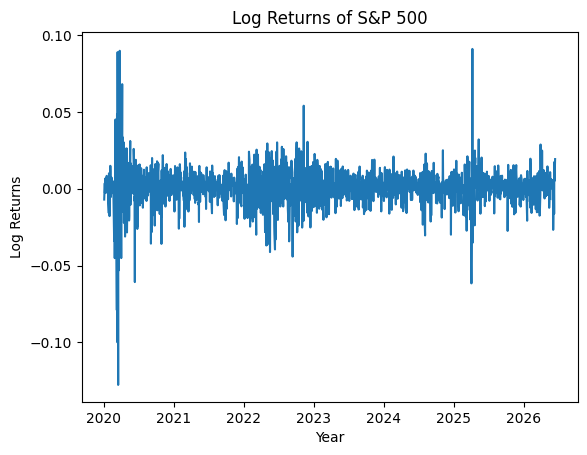

In [3]:
returns = load_logreturns()
prices =  load_prices()

plt.plot(returns)
plt.title("Log Returns of S&P 500")
plt.xlabel("Year")
plt.ylabel("Log Returns")
plt.show()


From visual inspection, volatility clustering appears apparent in the 2020 spike with increased volatility afterwards as well as lower magnitude clustering of large moves at different periods throughout the data.  We will quantify this below in the section "Temporal Characteristics."

To examine the assumption of Gaussian distributed increments we calculate the mean, std, and excess kurtosis so that we can compare the distribution of our data directly with a Gaussian distribution of the same mean and variance.

In [4]:
mean = np.mean(returns)
std = np.std(returns)
excess_kurtosis = kurtosis(returns)
# Since sci-kit calculates excess kurtosis (kurtosis - 3) by default, 
# for better readability we calculate kurtosis
kurtosis_ = excess_kurtosis + 3

print('The mean is:', mean)
print('The standard deviation is:', std)
print('The kurtosis is:', kurtosis_)

The mean is: 0.0005209287930547465
The standard deviation is: 0.012966847194677387
The kurtosis is: 17.771807378509443


We see that the mean is close to 0 relative to the standard deviation. Short term price movements are dominated by noise. 

The standard deviation is large relative to the mean, indicating substantial randomness and uncertainty in daily returns.

Though these two properties could be consistent with GBM the final property shows the first statistical property of our empirical asset data that violate the assumptions underlying GBM:

The S&P 500 time series data shows pronounced evidence of fat tails with kurtosis >> 3. Since Gaussian distributions have excess kurtosis of 3, this means that extreme events happen more often than Gaussian models (like GBM) predict. 

We have already reproduced one of the stylized facts (fat tails) and identified a statistical property our GBM model will fail to replicate. 

To compare our empirical data more directly with a Gaussian distribution we create a plot overlaying our data with a Gaussian distribution of the same mean and variance. 

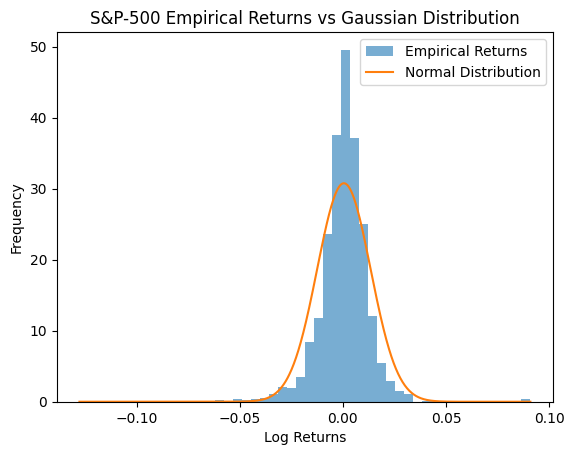

In [5]:
x = np.linspace(returns.min(), returns.max(), 1000)
gauss_y_val = norm.pdf(x, mean, std)

plt.hist(returns,bins=50,density=True, alpha=0.6,label='Empirical Returns')
plt.plot(x, gauss_y_val, label="Normal Distribution")
plt.title("S&P-500 Empirical Returns vs Gaussian Distribution")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("../images/Fat-tailed_S&P500Distribution")
plt.show()

As expected by the kurtosis of the data, we observe sharper peaks and fatter tails compared to the Gaussian benchmark.

The Gaussian model fails to capture the two extremes accurately. It understimates the likelyhood of both tiny movements and huge movements compared to the real observations in the empirical data. On the other hand, the Gaussian model overestimates the likelyhood of mid-sized movements.

Translating this empirical observation into the intuition of financial markets, our empirical data tells us that the market tends to spend a lot of time being relatively quiet while occasionally making huge moves. It alternates between calm regimes and turbulent regimes. This relates directly to the idea of volatility clustering. The Gaussian model assumes constant volatility.

### Temporal Structure

We will examine our data more closely looking for evidence of volatility clustering. To do this we plot the standard deviation over a rolling window of 20 days. This will give us a time series to examine the change of the volatility over time.

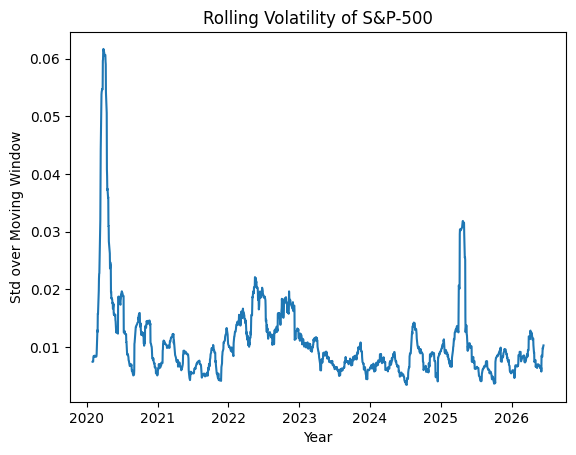

In [6]:
volatility = returns.rolling(20).std()
plt.plot(volatility)
plt.title("Rolling Volatility of S&P-500")
plt.xlabel("Year")
plt.ylabel("Std over Moving Window")
plt.show()


From the plot we can see that the volatility varies significantly over time. 

Periods of higher volatility tend to cluster together, suggesting that variance is time-dependent rather than constant. 

A Gaussian model assumes constant volatility, thus will not be able to capture this statistical property. 

### Autocorrelation

We now wish to examine the predictability of the returns as well as for volatility. For this we examine the autocorrelation of the returns and of the squared returns. Since volatility is related to magnitude, not direction, the squared returns serve as a rough approximation for the volatility:

In [7]:
autocorrelation_returns = returns.autocorr()
autocorrelation_squaredreturns = (returns**2).autocorr()
print('Autocorrelation of returns:', autocorrelation_returns)
print('Autocorrelation of squared returns:', autocorrelation_squaredreturns)

Autocorrelation of returns: -0.16553367897647514
Autocorrelation of squared returns: 0.4544569021557265


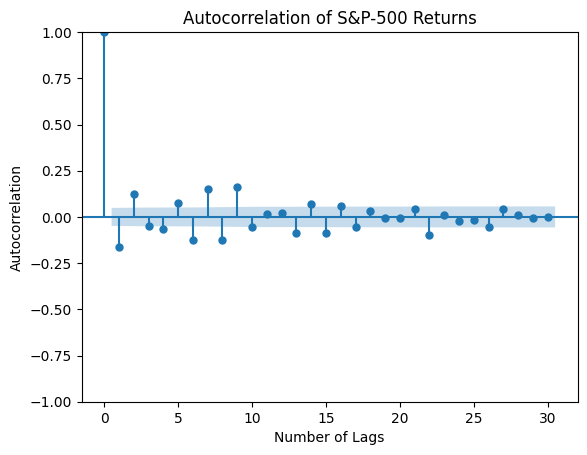

In [8]:
plot_acf(returns, lags=30)
plt.title("Autocorrelation of S&P-500 Returns")
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
plt.show()

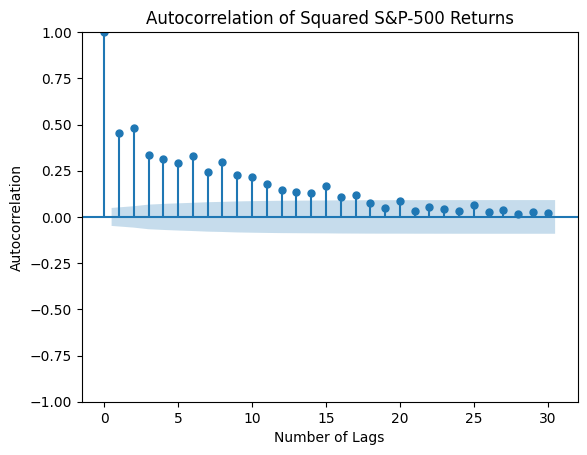

In [9]:
plot_acf(returns**2,lags=30)
plt.title("Autocorrelation of Squared S&P-500 Returns")
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
plt.show()

Comparing the two plots, we notice the ACF plot of the returns appears very noisy with no clear decay pattern. Despite having isolated statistically siginficant autocorrelation values outside of the confidence window, the values are still small and are likely a result of noise. This suggests limited linear predictability in returns themselves. 

On the other hand, the squared returns show consistent statistically significant autocorellation up to about 15 lags with slow linear decay with respect to the number of lags. This behavior is consistent with volatility clustering. 

Taking all these statistical facts together (kurtosis, heavy tails, volatility clustering) the higher order statistics of the S&P-500 demonstrate clearly non-Gaussian behavior. 

We will put these statistical observations to the test directly by building a GBM model and comparing the behavior directly.

## GBM Model
### Distributional Statistics

We import the GBM model. We first compare the prices and log returns simulated by a single GBM path.

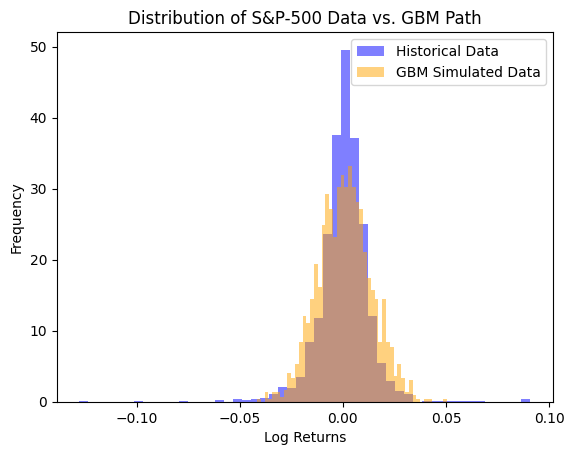

In [10]:
from src.gbm import simulate_GBM
simulated_prices = simulate_GBM(prices, returns)
simulated_logreturns = np.diff(np.log(simulated_prices))
plt.hist(returns, bins=50,alpha=0.5,density=True, color='blue', label="Historical Data")
plt.hist(simulated_logreturns, bins=50, alpha=0.5, density=True, color='orange',label="GBM Simulated Data")
plt.title("Distribution of S&P-500 Data vs. GBM Path")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()


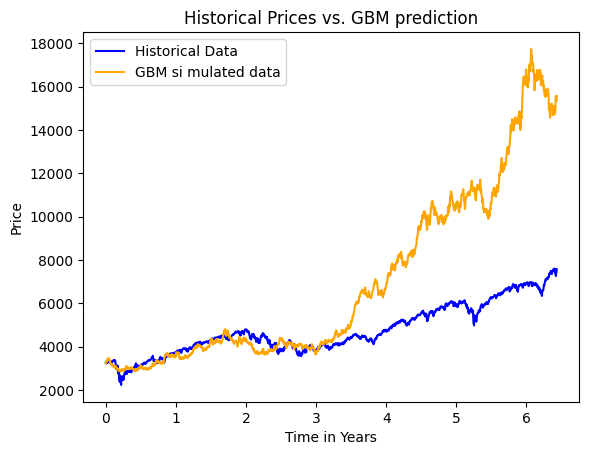

In [11]:
t = np.linspace(0, len(prices)/252, len(prices))
plt.plot(t, prices.values, color='blue', label='Historical Data')
plt.plot(t, simulated_prices, color='orange', label='GBM si mulated data')
plt.title('Historical Prices vs. GBM prediction')
plt.xlabel('Time in Years')
plt.ylabel('Price')
plt.legend()
plt.show()

We notice that the GBM very roughly models the S&P-500, generally following the same trend. The histogram comparison shows, similarily to the Gaussian overlay, that the true S&P-500 data has sharper peaks, heavier tails and less "mid-sized" movements compared to the GBM. 

We now increase the number of simulations in a Monte-Carlo type simulation and determine the average path of our GBM, plotting each simulation in comparison to the true S&P-500 data. 

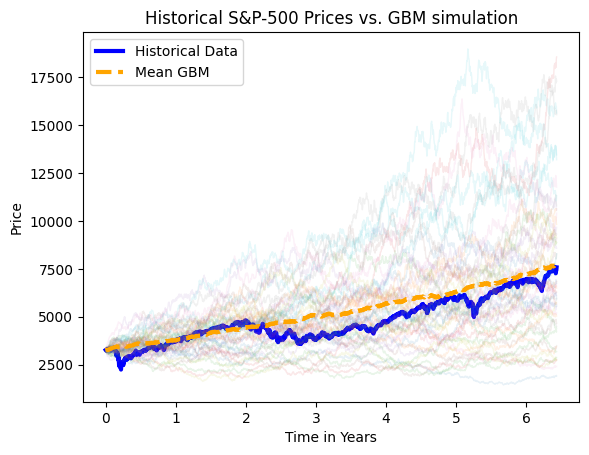

In [12]:
#number or simulations
n = 50
plt.plot(t, prices.values, color='blue',linewidth=3, label='Historical Data')
average_simprices = np.zeros((len(prices)))
all_sim_returns = []
for i in range(n):
    prices_estimate = simulate_GBM(prices, returns)
    average_simprices = (average_simprices + prices_estimate)
    sim_log_returns = np.diff(np.log(prices_estimate))
    all_sim_returns.extend(sim_log_returns)
    plt.plot(t, prices_estimate, alpha=0.1, linewidth=1)
average_simprices = average_simprices * 1/n 
plt.plot(t, average_simprices,color='orange', linewidth=3, linestyle='--', label='Mean GBM')  
plt.title("Historical S&P-500 Prices vs. GBM simulation")
plt.xlabel('Time in Years')
plt.ylabel('Price')
plt.legend()
plt.savefig("../images/GBMpathsvsSP500paths.png",dpi=300,bbox_inches="tight")
plt.show()

We now compare the histograms of the log returns of the historical data vs the simulated GBM paths. 

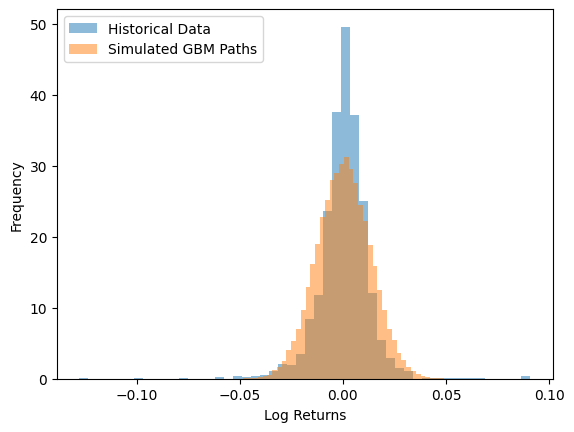

In [13]:
plt.hist(returns, bins=50, density=True, alpha=0.5,label="Historical Data")
plt.hist(all_sim_returns, bins=50,density=True,alpha=0.5,label='Simulated GBM Paths')
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Here we see that by increasing the number of GBM paths we approach a Gaussian distribution more closely. As predicted by our analysis of the historical data, the GBM model generally underestimates extreme daily movements (very small amplitude, or very large amplitude) and overestimates mid-sized movements. 

We now evaluate the kurtosis of our simulated returns.

In [14]:
all_simulated_excess_kurtosis = kurtosis(all_sim_returns)
# We convert the excess kurtosis calculated by default by scikit to kurtosis for better readability
all_simulated_kurtosis = all_simulated_excess_kurtosis + 3
simulated_excess_kurtosis = kurtosis(simulated_logreturns)
simulated_kurtosis = simulated_excess_kurtosis + 3
print('The kurtosis of the log returns of a single simulated GBM path is:', simulated_kurtosis)
print('The kurtosis of the log returs of many simulated GBM paths is:', all_simulated_kurtosis)

The kurtosis of the log returns of a single simulated GBM path is: 3.0324059942792507
The kurtosis of the log returs of many simulated GBM paths is: 2.9872579504595365


As expected the kurtosis of the simulated GBM paths is very close to 3
 only showing negligible evidence of heavy tails.

Now that we have compared the distributional statistics of the data vs. the GBM model we examine the temporal structure. 

### Temporal Structure

We compare the rolling volatility over a moving window of 20 days of our simulated GBM path to that of the S&P-500 data.

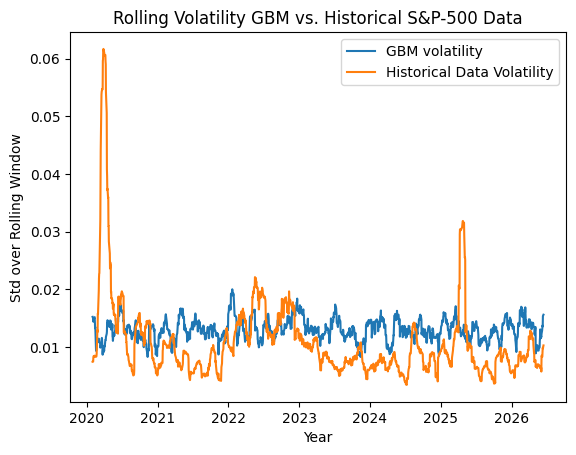

In [15]:
sim_log_returns = pd.Series(sim_log_returns, index=returns.index)
volatility_gbm = sim_log_returns.rolling(20).std()
plt.plot(volatility_gbm, label="GBM volatility")
plt.plot(volatility, label="Historical Data Volatility")
plt.title("Rolling Volatility GBM vs. Historical S&P-500 Data")
plt.xlabel("Year")
plt.ylabel("Std over Rolling Window")
plt.legend()
plt.savefig("../images/rolling_volatility_comparison.png",dpi=300,bbox_inches="tight")
plt.show()

Compared to the volatility of the historical data, the volatility of the simulated GBM path is relatively constant with only small fluctuations. The volatility of the historical data is roughly centered around the volatility of the GBM but exhibits much larger deviations. 

Since the GBM model is calibrated with the empirical standard deviation, the GBM model can capture the overall fluctuation magnitude but assumes constant volatility, which is not true for the historical data.

As we did for the historical data, we calculate the autocorrelation of the returns and of the squared returns. 

In [16]:
autocorrelation_gbmreturns = sim_log_returns.autocorr()
autocorrelation_squaredgbmreturns = (sim_log_returns**2).autocorr()
print('Autocorrelation of returns:', autocorrelation_gbmreturns)
print('Autocorrelation of squared returns:', autocorrelation_squaredgbmreturns)

Autocorrelation of returns: 0.01635447306785901
Autocorrelation of squared returns: -0.024430369501843154


Neither returns nor squared returns show significant autocorrelation. In contrast to the historical data, we see no signs of volatility clustering. GBM assumes constant volatility.  

We plot the ACF plots of returns and squared returns to examine this more deeply.

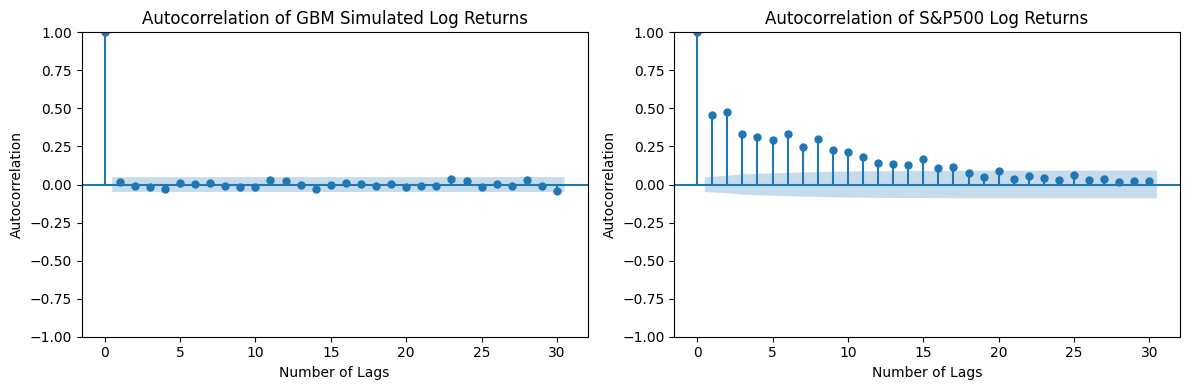

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(sim_log_returns, lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation of GBM Simulated Log Returns")
axes[0].set_xlabel("Number of Lags")
axes[0].set_ylabel("Autocorrelation")
plot_acf(returns**2, lags=30, ax=axes[1])
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
axes[1].set_title("Autocorrelation of S&P500 Log Returns")
axes[1].set_xlabel("Number of Lags")
axes[1].set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig("../images/SP500vsGBMReturnsAutocorrelation.png",dpi=300,bbox_inches="tight")
plt.show()

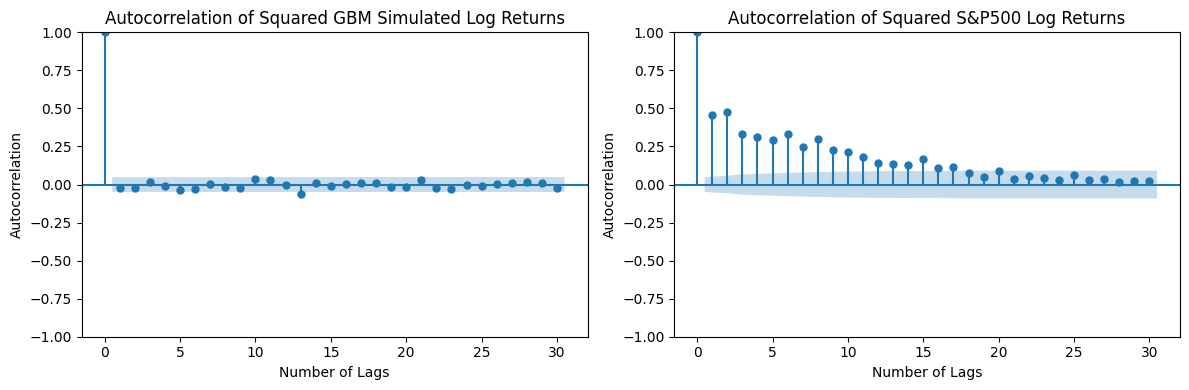

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(sim_log_returns**2, lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation of Squared GBM Simulated Log Returns")
axes[0].set_xlabel("Number of Lags")
axes[0].set_ylabel("Autocorrelation")
plot_acf(returns**2, lags=30, ax=axes[1])
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
axes[1].set_title("Autocorrelation of Squared S&P500 Log Returns")
axes[1].set_xlabel("Number of Lags")
axes[1].set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig("../images/SP500vsGBMSquaredReturnsAutocorrelation.png",dpi=300,bbox_inches="tight")
plt.show()

The ACF plots of the GBM model show that neither returns nor squared returns show significant autocorellation across lags, consistent with the assumption of independent Gaussian increments with only isolated spikes, randomly fluctuating near zero. 

This contrasts sharply with the historical data, where the squared returns showed significant autocorellation with a clear decay pattern. The GBM model fails to model the persistent volatility dynamics present in the historical data. 

### Final Analysis GBM Model vs. Historical S&P-500 Data
Our GBM Model calibrated to the historical data is able to reproduce some first order properties:
 
 - Both the empirical returns and simulated returns lack strong long-range autocorrelation structure. Still, the empirical data exhibits noticeably larger short-lag fluctuations than the GBM simulations, suggesting deviations from the iid increment assumption. 
 
 - The GBM paths reproduced a similar scale of fluctuations. The resulting paths exhibited qualitatively plausible stochastic price behavior. 

However, the GBM model failed to reproduce some higher order statistical properties: 
- The model showed kurtosis close to 3, while the historical data had kurtosis >> 3, showing pronounced heavy-tail structure. The Gaussian increment assumption significantly underestimates the frequency of extreme market movements.
- While the rolling volatility analysis of the historical data showed persistant periods of elevated and reduced volatility, the GBM simulations showed a much flatter rolling volatility curve with structureless fluctuations reflecting the models assumption of constant variance. 
- The empirical squared returns exhibited persistent positive autocorrelation with a marked decay structure, indicating volatility clustering and time-varying variance. The GBM model showed squared-return autocorrelations fluctuating near zero, consistent with independent increments and constant volatility.

The analysis suggests that financial time series cannot fully be characterized by low-order statistics such as mean and variance. Temporal dependence in volatility-related quantities constitutes an important aspect of market dynamics absent from the classical GBM framework.

The observed differences in the simulated data vs. the historical S&P-500 data are caused directly by the assumptions of the GBM, particularly the assumptions of iid Gaussian increments and constant volatility. While these assumptions yield a mathematically elegant stochastic framework, they do not adequately reproduce the higher-order structure observed in empirical market data. 

Despite these limitations, the GBM remains an important baseline model due to its analytical simplicity and its central role in classical quantitative finance i.e. the derivation of the Black-Scholes framework. 

The observed persistence in volatility-related quantities naturally motivates more sophisticated stochastic models that incorporate time-varying or stochastic volatility such as GARCH.

This motivates us to the second part of this project, where we see if we can capture some of these higher order statistical properties through machine learning.

## Machine Learning Models to capture Higher-Order Structure

The analysis of the S&P-500 historical data compared with the GBM simulations indicates, that although return directions are difficult to predict, volatility-related quantities exhibit persistent temporal dependence absent from the GBM framework. This distinction motivates the transition from classical diffusion-based modeling towards machine learning approaches focused on predicting conditional volatility dynamics. 

We will implement three machine learning models of increasing complexity: linear regression model, Random Forrest algorithm, and a feed forward neural network. As our target we choose 5-day realized volatility shifted 5 trading days ahead. 

We begin with the linear regression model. 

### Training and Test Data

In [19]:
# Data preparation

# We split our features data frame into data X and target Y. 
# As our target we choose the future realized volatility (calculated as std over rolling window of 5 days) 5 trading days into the future

features = create_features(returns)
X = features.drop(columns=["target"])
y = features["target"] 

# Since we are working with time series data, the data has to be split chronologically, 
# not randomly to avoid look ahead bias and keep the temporal structure relevant to our features intact.
# For simplicity and readability for this notebook we choose a single split.
# For more rigorous validation in other contexts I would consider for instance walk forward split 

splitting_index = int(len(features)* 0.8)
X_train = X[:splitting_index]
X_test = X[splitting_index:]
Y_train = y[:splitting_index]
Y_test = y[splitting_index:]


### Feature Baseline
We first train our models on a collection features we choose motivated by our previous analysis. After training the models we will re-examine the selection of features based on their correlation. We choose each feature to capture a different characteristic of our time series data that could be useful for predicting volatility: 
- **Log Returns** to capture pointwise directional shocks
- **Realized volatility** calculated over rolling window (i.e  returns.rolling(vol_window).std): this captures local volatility structure, medium-term volatility state
- **Lagged realized volatility** with lags 1, 5, 10 to capture volatility persistence in short, medium and long term
- **Absolute returns** to capture shock magnitude
- **Squared returns** as a pointwise volatility proxy
- **Rolling mean** to capture local directional regime
- **Rolling kurtosis** to capture information about changes in likelyhood  of extreme movements

### Linear Regression model
Since our data showed signs of volatility persistence with strong linear autocorrelation in squared returns, a basic linear model should show some sucess. We compare our linear model vs. a naive prediction, relying only on volatility persistence, predicting the current realized volatility as the future volatility at every moment. 

In [20]:
linear_model, scaler = train_linear_regression(X_train, Y_train)
X_train_scaled = scaler.transform(X_train)
pred_train = model_prediction(linear_model, X_train_scaled)
pred_train = pd.Series(pred_train, index=Y_train.index)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns, index=X_train.index)
pred_test = model_prediction(linear_model, X_test_scaled)
pred_test = pd.Series(pred_test, index=Y_test.index)
evaluate_performance("Linear Regression", pred_train, pred_test, Y_train, Y_test)
naive_pred_train = X_train["realized_vol"]
naive_pred_test = X_test["realized_vol"]
compare_prediction("Test Prediction Results Linear Model vs. Naive Model", pred_test, "Linear Model", naive_pred_test, "Naive Prediction", Y_test)


Linear Regression Model Performance on Training Data vs. Test Data
------------------------------------------------------------------
       Data Set       MAE       MSE       R^2
0  Training Set  0.003863  0.000037  0.522249
1      Test Set  0.003991  0.000040  0.231988

Test Prediction Results Linear Model vs. Naive Model
----------------------------------------------------
              Model       MAE       MSE       R^2  \
0      Linear Model  0.003991  0.000040  0.231988   
1  Naive Prediction  0.004703  0.000059 -0.124954   

   Strictly Lower Error Frequency (%)  
0                              57.812  
1                              42.188  


The naive baseline shows limited predictive power with high MAE and negative R2. Volatity persistence on its own is insufficient for predicting the 5 day ahead realized volatility.  The linear regression model shows a significant improvement over the naive model, achieving an R2 of approximately 0.23 and a decrease in MAE of around 15 percent as well as an improvement in MSE of 32 percent. This suggests that the linear model greatly reduces large magnitude errors.  

We examine if we can achieve better results through further refining our features. 
### Feature Selection - Linear Regression
For our feature selection we examine the standard coefficients of our features, we sort them by magnitude and plot them for easier interpretability. 

In [22]:
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": linear_model.coef_
})
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)
print(coef_df)

                   Feature  Coefficient
1             realized_vol     0.002521
7             rolling_mean    -0.001211
2                 vol_lag1     0.001172
3                 vol_lag5     0.001153
5               abs_return     0.001063
0                  returns    -0.000760
6                sq_return     0.000257
4                vol_lag10    -0.000049
8  rolling_excess_kurtosis     0.000014


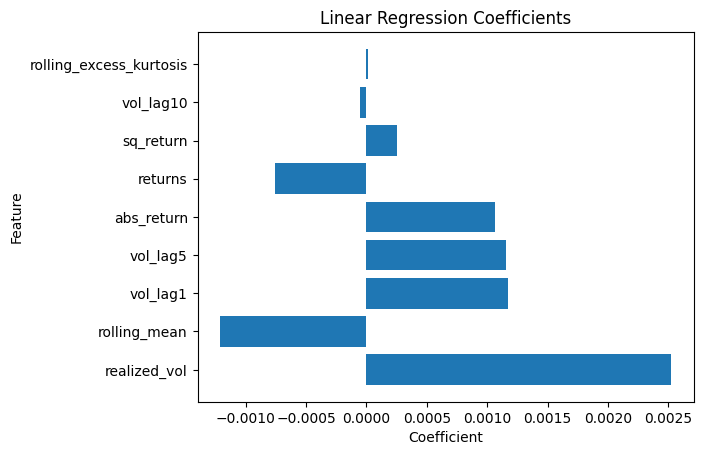

In [21]:
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Linear Regression Coefficients")
plt.ylabel("Feature")
plt.xlabel("Coefficient")
plt.show()

We notice that current realized_volatility has the highest predictive power for our linear model. This is to be expected from our previous analysis. Due to the pronounced volatility persistence present in our data current volatility has strong linear correlation with future volatility. 

Interestingly rolling_mean is second in magnitude of standard coefficient but with a negative sign. This suggests the model has learned some type of leverage effect: periods of negative average log returns correlate with increased volatility whereas periods of positive average log returns correlate with decreased volatility. 

The "short" and "medium-term"-memory volatility features as well as the pointwise volatility approximation abs returns all seem to add some incremental information. 

Squared returns, vol_lag10 and rolling_excess_kurtosis all seem to hold limited incremental predictive power. The predictive information contained in squared_returns is likely already contained in abs_returns: the magnitude of daily shocks. The lack of incremental information in vol_lag10 coincides with our analysis above, since we noticed a clear decay structure in the linear volatility autocorrelation. Rolling_excess_kurtosis also seems to have no linear predictive power for future volatility. We will see later whether it contains nonlinear predictive power.

We will remove these three features and compare performance. 

In [23]:
X_train_reduced = X_train.drop(columns=['rolling_excess_kurtosis','sq_return', 'vol_lag10'])
X_test_reduced = X_test.drop(columns=['rolling_excess_kurtosis', 'sq_return','vol_lag10'])

linear_model_reducedfeatures, scaler_reduced = train_linear_regression(X_train_reduced, Y_train)
X_train_reduced_scaled = scaler_reduced.transform(X_train_reduced)
pred_train_reduced = model_prediction(linear_model_reducedfeatures, X_train_reduced_scaled)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)
X_train_reduced_scaled = pd.DataFrame(X_train_reduced_scaled,columns=X_train_reduced.columns, index=X_train_reduced.index)
pred_test_reduced = model_prediction(linear_model_reducedfeatures, X_test_reduced_scaled)
pred_test_reduced = pd.Series(pred_test_reduced, index=Y_test.index)
evaluate_performance("Reduced Linear Model", pred_train_reduced, pred_test_reduced,Y_train, Y_test)

compare_prediction("Comparision Reduced Linear Model vs Full Feature Linear model on Test Data", pred_test,"Full Feature Linear Model", pred_test_reduced,"Reduced Feature Linear Model", Y_test)


Reduced Linear Model Model Performance on Training Data vs. Test Data
---------------------------------------------------------------------
       Data Set       MAE       MSE       R^2
0  Training Set  0.003870  0.000037  0.521972
1      Test Set  0.003992  0.000040  0.231506

Comparision Reduced Linear Model vs Full Feature Linear model on Test Data
--------------------------------------------------------------------------
                          Model       MAE      MSE       R^2  \
0     Full Feature Linear Model  0.003991  0.00004  0.231988   
1  Reduced Feature Linear Model  0.003992  0.00004  0.231506   

   Strictly Lower Error Frequency (%)  
0                              53.438  
1                              46.562  


We notice the model keeps almost all of its predictive power with the reduced set of features. 

Thus, we continue with the more compact set of features and now only refer to the linear model with reduced features as the linear model. 

### Linear Regression vs. Naive Baseline Model

We plot the predicted volativity of the naive and linear regression model vs. the realized volatility. 

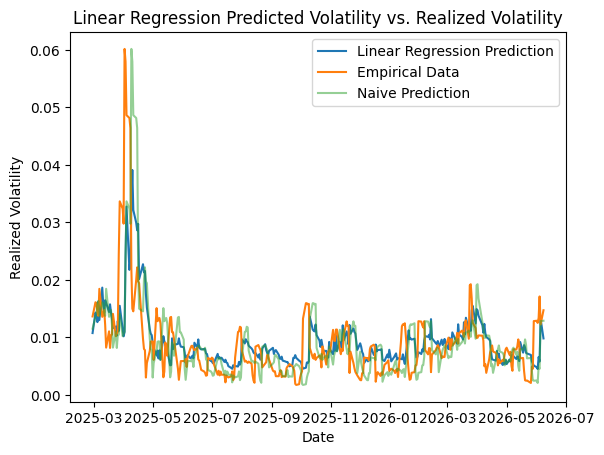

In [24]:
plt.plot(pred_test_reduced,label="Linear Regression Prediction")
plt.plot(Y_test, label="Empirical Data")
plt.plot(naive_pred_test,label="Naive Prediction",alpha=0.5)
plt.legend()
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.title("Linear Regression Predicted Volatility vs. Realized Volatility")
plt.show()

The naive prediction accumulates large errors during the short high peaks due to its time lag. During stable periods the naive model does relatively well. Despite the linear model not being able to predict the magnitude of the peaks well, its timing improvement results in an overall siginificant reduction in MAE and especially reduction in very large magnitude errors. 



We move on to the Random Forest model to see if we can achieve better results by relaxing the linearity assumption underlyling linear regression. 

### Random Forest Model
We move on to a Random Forest model to see if by capturing nonlinear relationships in the volatility forecasting features we can improve upon the predictive power of the linear model and a more marked difference to the predictive power of the naive model. 

Since the features we trimmed from the linear model could have some non-linear predictive power not captured by the coefficient analysis for the linear model we start with the full feature set. 



In [25]:
rf_model = train_random_forest(X_train, Y_train)
pred_train_rf = model_prediction(rf_model, X_train)
pred_test_rf = model_prediction(rf_model, X_test)
pred_train_rf = pd.Series(pred_train_rf, index=Y_train.index)
pred_test_rf = pd.Series(pred_test_rf, index=Y_test.index)
evaluate_performance("Random Forest",pred_train_rf, pred_test_rf, Y_train, Y_test)
compare_prediction("Performance of Random Forest vs Linear Model on Test Data",pred_test_rf, "Random Forest Model",pred_test_reduced,"Linear Model", Y_test)




Random Forest Model Performance on Training Data vs. Test Data
--------------------------------------------------------------
       Data Set       MAE       MSE       R^2
0  Training Set  0.003722  0.000032  0.587211
1      Test Set  0.004059  0.000043  0.186604

Performance of Random Forest vs Linear Model on Test Data
---------------------------------------------------------
                 Model       MAE       MSE       R^2  \
0  Random Forest Model  0.004059  0.000043  0.186604   
1         Linear Model  0.003992  0.000040  0.231506   

   Strictly Lower Error Frequency (%)  
0                              48.438  
1                              51.562  


We notice the Random forest shows significant overfitting and performs significantly worse than the linear model, with a MAE around double that of the linear model. 

To diagnose the failure of the random forest model we examine the ranges of the issue we look at the ranges of the test data vs the predictions of the linear and random forest models. 

In [26]:
print(f"Min of training data: {Y_train.min()}, Max of training data: {Y_train.max()}")
print(f"Min of test data: {Y_test.min()}, Max of test data: {Y_test.max()}")
print(f"Min of RF train prediction: {pred_train_rf.min()}, Max of RF train prediction: {pred_train_rf.max()}")
print(f"Min of RF test prediction: {pred_test_rf.min()}, Max of RF test prediction: {pred_test_rf.max()}")
print(f"Min of Linear Test Prediction: {pred_train_reduced.min()}, Max of Linear train Prediction: {pred_train_reduced.max()}")
print(f"Min of Linear Test Prediction: {pred_test_reduced.min()}, Max of Linear test Prediction: {pred_test_reduced.max()}")


Min of training data: 0.0009029486724619018, Max of training data: 0.0959351864044456
Min of test data: 0.0017468648420013917, Max of test data: 0.060162387525219754
Min of RF train prediction: 0.007759107594423231, Max of RF train prediction: 0.04594930449107888
Min of RF test prediction: 0.007759107594423229, Max of RF test prediction: 0.043426815726634746
Min of Linear Test Prediction: 0.0036793838463871787, Max of Linear train Prediction: 0.07835107462068228
Min of Linear Test Prediction: 0.004514798408550605, Max of Linear test Prediction: 0.03911856848156381


While the linear model is able to match the range of the training and test data well, the random forest model produces a range that differs substantially from the actual range for both training and test data. In addition the range of its predictions are nearly identical range for training and test data despite the actual range of the test data being much narrower.

Whereas a linear regression model  is able to extrapolate the correct prediction range, a forest cannot, since it averages observations that fall into the same leaves. This produces predictions skewed toward the center of the training distribution. We notice the result is that the range is both too narrow for the training data and too wide for the test data. 

The random forest appears to scale its predictions on the test data based off of the learned range in the training data, producing large errors compared to the linear model.

To test this more we plot the Random Forest predictions directly compared to the data.

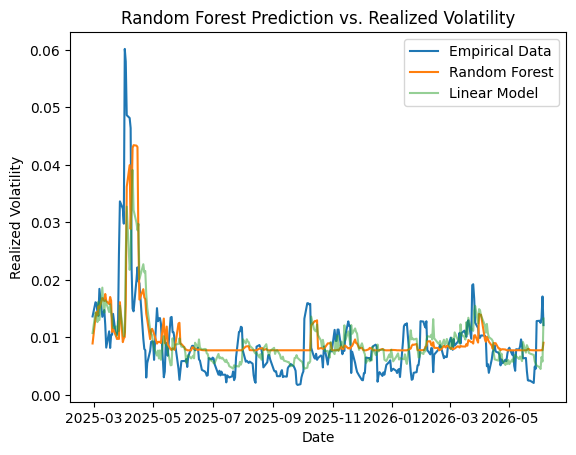

In [27]:
plt.plot(Y_test, label="Empirical Data")
plt.plot(pred_test_rf, label="Random Forest")
plt.plot(pred_test_reduced, label="Linear Model", alpha=0.5)
plt.title("Random Forest Prediction vs. Realized Volatility")
plt.ylabel("Realized Volatility")
plt.xlabel("Date")
plt.legend()
plt.show()

As we predicted above, the random forest model appears to scale its predictions based off of the range it learned in the training data.

The model produces "step-function"-like predictions (i.e. piecewise constant) characteristic of tree models due to its predictions being produced by averaging leaf values. While it does react to regime changes (higher in May 2025, lower in September 2025), it follows the actual shape of the volatility curve much less smoothly than the linear model due to its step-function like predictions. 

Despite the model's poor performance, we could still gleam valuable feature importance info for non-linear models from it to add to our analysis of features for linear regression. We examine the feature importances.

### Feature Selection - Random Forest


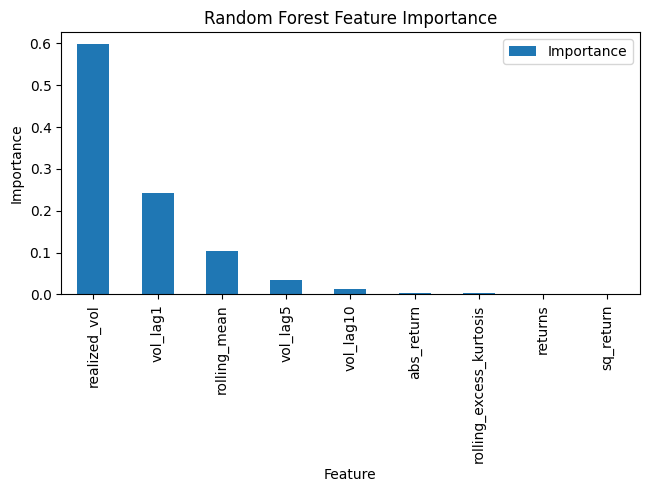

In [28]:
importance_df = pd.DataFrame({
"Feature": X_train.columns,
"Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)
plt.tight_layout()
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()


We notice rolling kurtosis and squared returns again holds no predictive power for our model. The only features that held predictive power for the Random forest model are the immediate short term memory volatility persistence features: realized volatility and volatility_lag1. 

We remove the other features and compare performance. 

In [29]:
X_train_reduced_rf = X_train.drop(
    columns=['rolling_excess_kurtosis','abs_return', 'returns', 'vol_lag10', 'sq_return', 'vol_lag5', 'rolling_mean']
    )
X_test_reduced_rf = X_test.drop(
    columns=['rolling_excess_kurtosis','abs_return', 'returns', 'vol_lag10', 'sq_return', 'vol_lag5', 'rolling_mean']
    )

rf_model_reduced = train_random_forest(X_train_reduced_rf, Y_train)
pred_train_rf_reduced = model_prediction(rf_model_reduced, X_train_reduced_rf)

pred_test_rf_reduced = model_prediction(rf_model_reduced, X_test_reduced_rf)
pred_test_rf_reduced = pd.Series(pred_test_rf_reduced, index=Y_test.index)
pred_train_rf_reduced = pd.Series(pred_train_rf_reduced, index=Y_train.index)
evaluate_performance("Reduced Random Forest",pred_train_rf_reduced,pred_test_rf_reduced, Y_train, Y_test)
compare_prediction("Test Data Performance Comparision Reduced Randon Forest vs Full Random Forest",pred_test_rf, "Random Forest Test Full Features", pred_test_rf_reduced, "Random Forest Reduced", Y_test)



Reduced Random Forest Model Performance on Training Data vs. Test Data
----------------------------------------------------------------------
       Data Set       MAE       MSE       R^2
0  Training Set  0.003889  0.000035  0.550078
1      Test Set  0.004139  0.000046  0.119947

Test Data Performance Comparision Reduced Randon Forest vs Full Random Forest
-----------------------------------------------------------------------------
                              Model       MAE       MSE       R^2  \
0  Random Forest Test Full Features  0.004053  0.000043  0.186918   
1             Random Forest Reduced  0.004139  0.000046  0.119947   

   Strictly Lower Error Frequency (%)  
0                              48.589  
1                              51.411  


The reduced model retains essentially all of its predictive power, showing almost identical metrics (MAE, MSE, R^2) for both the test and training data. This suggests the removed features contained little incremental information for forecasting future volatility and predictive power is concentrated in the lagged volatility features. 

Both the Random Forest model and linear model detected the features realized_volatility and vol_lag1 as the most impactful features. Features measuring past volatility held the most predictive power, suggesting strong volatility persistence.

### Conclusion Random Forest vs. Linear Model
Despite having the ability to detect nonlinear relationships, the Random Forest model was not able to out-perform the linear model. The observation-averaging property of the random forest algorithm which has the consequence that predictions are skewed towards the mean of the training data, proved very detrimental to volatility forecasting. Since empirical volatility tends to spend most of the time in calm periods with occasional huge spikes of different magnitudes, the random forest model's observation-averaging methodology and inability to extrapulate resulted in huge errors. It produced huge overestimates for both high volatility periods and low volatility periods in the test data based on its mean-skewed training data range. 

The random forest predictions showed step-function like behavior so that it was unable to follow the volatility curve as closely as the linear model. Our analysis until now suggests linear volatility relationships dominate in predictive power. 

Next we will test whether a neural network, which is neither bounded by linearity nor bounded to observation averaging can outperform both models. 

### Neural Network Model
We choose a basic feed-forward network as our comparison model with 3 layers: a 32 unit layer with ReLu activation, a 16 unit layer with ReLu activation, and the output layer with linear activation. 

In [30]:
X_train_nn = X_train.to_numpy(dtype=np.float32)
X_test_nn = X_test.to_numpy(dtype=np.float32)
y_train_nn = Y_train.to_numpy(dtype=np.float32)

In [31]:
neural_model, history = train_reduced_neural_network(X_train_nn, y_train_nn,[130,60])
print(history.history["loss"][-1])
print(history.history["val_loss"][-1])
y_pred_neural_train = model_prediction(neural_model, X_train_nn)
y_pred_neural_test = model_prediction(neural_model, X_test_nn)
y_pred_neural_train = pd.Series(y_pred_neural_train.flatten(), index=Y_train.index)
y_pred_neural_test = pd.Series(y_pred_neural_test.flatten(), index=Y_test.index)
evaluate_performance("Neural Network", y_pred_neural_train, y_pred_neural_test, Y_train, Y_test)
compare_prediction("Linear Model vs Neural Model Prediction", y_pred_neural_test,"Neural Model", pred_test_reduced,"Linear Model", Y_test)
results = choose_architecture(X_train, Y_train, X_test, Y_test)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.1258 - mse: 0.0488 - val_loss: 0.0282 - val_mse: 0.0014
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0792 - mse: 0.0187 - val_loss: 0.0165 - val_mse: 7.4350e-04
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0525 - mse: 0.0164 - val_loss: 0.0092 - val_mse: 1.8712e-04
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0355 - mse: 0.0055 - val_loss: 0.0068 - val_mse: 9.0253e-05
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0267 - mse: 0.0041 - val_loss: 0.0045 - val_mse: 4.0707e-05
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0181 - mse: 0.0022 - val_loss: 0.0040 - val_mse: 3.6126e-05
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0140 - mse: 0.0015 - val_loss: 0.0035 - val_mse: 3.1605e-05
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0101 - mse: 7.3377e-04 - val_loss: 0.0037 - val_mse: 3.4428e-05
Epoch 9/1000
32/

In [33]:
neural_model_optimized, history_optimized = train_reduced_neural_network(X_train_nn, y_train_nn,[128,64])
print(history_optimized.history["loss"][-1])
print(history_optimized.history["val_loss"][-1])
y_pred_neural_train = model_prediction(neural_model_optimized, X_train_nn)
y_pred_neural_test = model_prediction(neural_model_optimized, X_test_nn)
y_pred_neural_train = pd.Series(y_pred_neural_train.flatten(), index=Y_train.index)
y_pred_neural_test = pd.Series(y_pred_neural_test.flatten(), index=Y_test.index)
evaluate_performance("Neural Network", y_pred_neural_train, y_pred_neural_test, Y_train, Y_test)
compare_prediction("Linear Model vs Neural Model Prediction", y_pred_neural_test,"Neural Model", pred_test_reduced,"Linear Model", Y_test)


Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.1116 - mse: 0.0387 - val_loss: 0.0251 - val_mse: 0.0013
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0708 - mse: 0.0170 - val_loss: 0.0182 - val_mse: 6.0507e-04
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0483 - mse: 0.0071 - val_loss: 0.0147 - val_mse: 5.2100e-04
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0382 - mse: 0.0065 - val_loss: 0.0089 - val_mse: 1.6610e-04
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0262 - mse: 0.0030 - val_loss: 0.0068 - val_mse: 1.1283e-04
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0176 - mse: 0.0014 - val_loss: 0.0055 - val_mse: 7.7122e-05
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0138 - mse: 8.2315e-04 - val_loss: 0.0044 - val_mse: 5.1654e-05
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0112 - mse: 5.0192e-04 - val_loss: 0.0039 - val_mse: 4.1730e-05
Epoch 9/1000

In [34]:
results = validate_seed_robustness(X_train, Y_train, X_test, Y_test)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.1097 - mse: 0.0528 - val_loss: 0.0200 - val_mse: 6.3112e-04
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0701 - mse: 0.0262 - val_loss: 0.0200 - val_mse: 6.8235e-04
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0485 - mse: 0.0164 - val_loss: 0.0131 - val_mse: 3.4126e-04
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0384 - mse: 0.0132 - val_loss: 0.0085 - val_mse: 2.2515e-04
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0265 - mse: 0.0084 - val_loss: 0.0067 - val_mse: 7.5337e-05
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0188 - mse: 0.0031 - val_loss: 0.0058 - val_mse: 1.3461e-04
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0146 - mse: 0.0015 - val_loss: 0.0036 - val_mse: 2.3418e-05
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0124 - mse: 0.0012 - val_loss: 0.0038 - val_mse: 2.4639e-05
Epoch 9/1000
32/

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

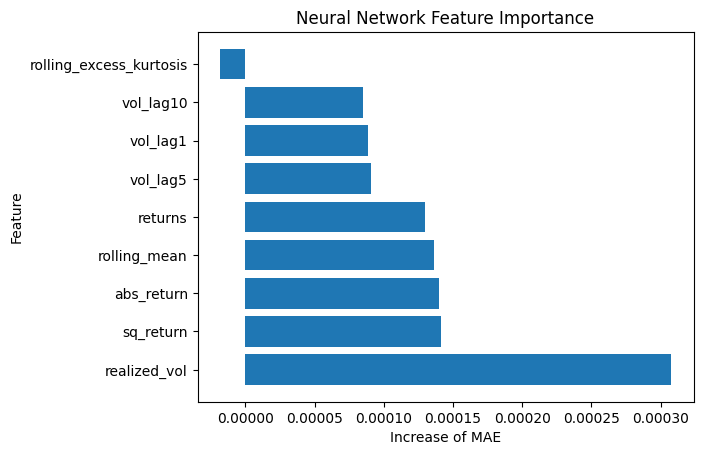

In [33]:
feature_results = find_feature_importance(neural_model_optimized,X_test,Y_test)
importance_nn = pd.DataFrame(feature_results.items(), columns=["Feature", "Importance"]).sort_values("Importance", ascending=False)
plt.barh(importance_nn["Feature"], importance_nn["Importance"])
plt.title("Neural Network Feature Importance")
plt.ylabel("Feature")
plt.xlabel("Increase of MAE")
plt.show()

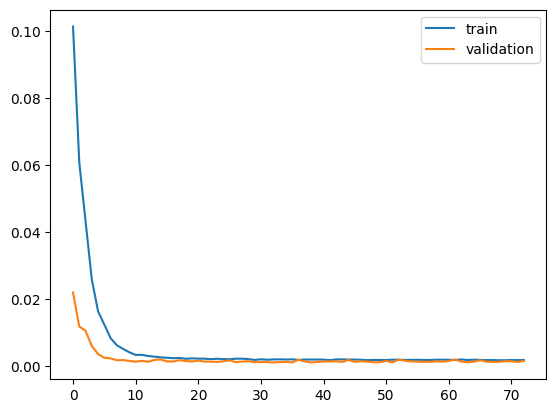

In [32]:
plt.plot(history_optimized.history["loss"], label="train")
plt.plot(history_optimized.history["val_loss"],label="validation")
plt.legend()
plt.show()

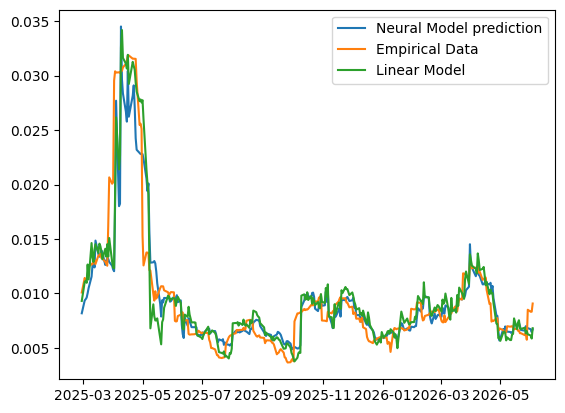

In [43]:
plt.plot(y_pred_neural_test, label="Neural Model prediction")
plt.plot(Y_test, label="Empirical Data")
plt.plot(pred_test_reduced, label="Linear Model")
plt.legend()
plt.show()

In [32]:
X_train_nn_minimal_reduced = X_train_reduced_rf.to_numpy(dtype=np.float32)
X_test_nn_minimal_reduced = X_test_reduced_rf.to_numpy(dtype=np.float32)
neural_model_minimal_reduced, history_minimal_reduced = train_neural_network(X_train_nn_minimal_reduced, y_train_nn)
print(history_minimal_reduced.history["loss"][-1])
print(history_minimal_reduced.history["val_loss"][-1])
y_pred_neural_train_minimal_reduced = model_prediction(neural_model_minimal_reduced, X_train_nn_minimal_reduced)
y_pred_neural_test_minimal_reduced = model_prediction(neural_model_minimal_reduced, X_test_nn_minimal_reduced)
y_pred_neural_train_minimal_reduced = pd.Series(y_pred_neural_train_minimal_reduced.flatten(), index=Y_train.index)
y_pred_neural_test_minimal_reduced = pd.Series(y_pred_neural_test_minimal_reduced.flatten(), index=Y_test.index)
evaluate_performance("Minimal Reduced Neural Network", y_pred_neural_train_minimal_reduced, y_pred_neural_test_minimal_reduced, Y_train, Y_test)
compare_prediction("Minimal Feature Neural Network vs Full Feature Neural Model Prediction", y_pred_neural_test_minimal_reduced,"Minimal Feature Neural Model", y_pred_neural_test,"Full Feature Neural Model", Y_test)
result_minimal = validate_seed_robustness(X_train_reduced_rf, Y_train, X_test_reduced_rf, Y_test)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0456 - mse: 0.0091 - val_loss: 0.0118 - val_mse: 1.9197e-04
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0254 - mse: 0.0041 - val_loss: 0.0027 - val_mse: 1.0485e-05
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0148 - mse: 0.0014 - val_loss: 0.0019 - val_mse: 6.1382e-06
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0106 - mse: 0.0011 - val_loss: 0.0020 - val_mse: 6.9912e-06
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0078 - mse: 6.5375e-04 - val_loss: 0.0011 - val_mse: 1.9713e-06
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0052 - mse: 2.1021e-04 - val_loss: 0.0013 - val_mse: 2.4125e-06
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0047 - mse: 2.5878e-04 - val_loss: 0.0016 - val_mse: 3.8992e-06
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0035 - mse: 1.0017e-04 - val_loss: 0.0018 - val_mse: 4.5116e-06


In [33]:
X_train_reduced_fivefeatures= X_train.drop(columns=['returns','sq_return','abs_return', 'vol_lag10'])
X_train_nn_reduced = X_train_reduced_fivefeatures.to_numpy(dtype=np.float32)
X_test_reduced_fivefeatures = X_test.drop(columns=['returns','sq_return','abs_return', 'vol_lag10'])
X_test_nn_reduced = X_test_reduced_fivefeatures.to_numpy(dtype=np.float32)
neural_model_reduced, history_reduced = train_neural_network(X_train_nn_reduced, y_train_nn)
print(history_reduced.history["loss"][-1])
print(history_reduced.history["val_loss"][-1])
y_pred_neural_train_reduced = model_prediction(neural_model_reduced, X_train_nn_reduced)
y_pred_neural_test_reduced = model_prediction(neural_model_reduced, X_test_nn_reduced)
y_pred_neural_train_reduced = pd.Series(y_pred_neural_train_reduced.flatten(), index=Y_train.index)
y_pred_neural_test_reduced = pd.Series(y_pred_neural_test_reduced.flatten(), index=Y_test.index)
evaluate_performance("Reduced Neural Network", y_pred_neural_train_reduced, y_pred_neural_test_reduced, Y_train, Y_test)
compare_prediction("Reduced Neural Model vs Full Feauture Neural Model Prediction", y_pred_neural_test_reduced,"Reduced Feature Neural Model", y_pred_neural_test,"Full Feature Neural Model", Y_test)
validate_seed_robustness(X_train_reduced_fivefeatures, Y_train, X_test_reduced_fivefeatures, Y_test)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0816 - mse: 0.0250 - val_loss: 0.0291 - val_mse: 0.0012
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0439 - mse: 0.0069 - val_loss: 0.0148 - val_mse: 2.9782e-04
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0273 - mse: 0.0029 - val_loss: 0.0077 - val_mse: 8.0110e-05
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0182 - mse: 0.0018 - val_loss: 0.0040 - val_mse: 2.4516e-05
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0116 - mse: 9.4074e-04 - val_loss: 0.0016 - val_mse: 3.6456e-06
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0064 - mse: 2.5548e-04 - val_loss: 0.0019 - val_mse: 5.5305e-06
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0048 - mse: 1.7901e-04 - val_loss: 0.0014 - val_mse: 3.0254e-06
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0037 - mse: 8.2017e-05 - val_loss: 0.0012 - val_mse: 2.3661e-06
Epoc

[0.0015334687054879479,
 0.0013411936939335264,
 0.0012904382292850153,
 0.0014282219293334391,
 0.0014480324104964586,
 0.0013629645134807455,
 0.0014870232338889103,
 0.0015174745118484941,
 0.0014754259120769756]

In [35]:
X_train_nn_reduced = X_train_reduced_rf.to_numpy(dtype=np.float32)
X_test_nn_reduced = X_test_reduced_rf.to_numpy(dtype=np.float32)
neural_model_reduced, history_reduced = train_reduced_neural_network(X_train_nn_reduced, y_train_nn, [256, 128])
print(history_reduced.history["loss"][-1])
print(history_reduced.history["val_loss"][-1])
y_pred_neural_train_reduced = model_prediction(neural_model_reduced, X_train_nn_reduced)
y_pred_neural_test_reduced = model_prediction(neural_model_reduced, X_test_nn_reduced)
y_pred_neural_train_reduced = pd.Series(y_pred_neural_train_reduced.flatten(), index=Y_train.index)
y_pred_neural_test_reduced = pd.Series(y_pred_neural_test_reduced.flatten(), index=Y_test.index)
evaluate_performance("Neural Network", y_pred_neural_train_reduced, y_pred_neural_test_reduced, Y_train, Y_test)
compare_prediction("Linear Model vs Neural Model Prediction", y_pred_neural_test_reduced,"Neural Model", pred_test_reduced,"Linear Model", Y_test)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.0399 - mse: 0.0093 - val_loss: 0.0055 - val_mse: 3.5621e-05
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0192 - mse: 0.0023 - val_loss: 0.0059 - val_mse: 6.0727e-05
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0117 - mse: 0.0012 - val_loss: 0.0013 - val_mse: 2.6001e-06
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0079 - mse: 6.1076e-04 - val_loss: 0.0011 - val_mse: 1.9655e-06
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0074 - mse: 8.7772e-04 - val_loss: 0.0011 - val_mse: 1.8464e-06
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0047 - mse: 2.1685e-04 - val_loss: 0.0011 - val_mse: 1.7733e-06
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0036 - mse: 1.4025e-04 - val_loss: 0.0011 - val_mse: 1.9513e-06
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0033 - mse: 9.4311e-05 - val_loss: 0.0011 - val_mse: 1.8325e